# EDA
( just doing some post cleaning EDA, to see if pipeline actually works, and perhaps needed for report later on )

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'master' in file.lower() or 'f1' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/f1_circuits.xml
/content/drive/MyDrive/JSON-F1-full (1).json
/content/drive/MyDrive/df_master.csv
/content/drive/MyDrive/Colab Notebooks/Copy of F1_notebook.ipynb
/content/drive/MyDrive/Colab Notebooks/F1_notebook.ipynb
/content/drive/MyDrive/Colab Notebooks/Carmen_F1notebook.ipynb


In [5]:
df = pd.read_csv('/content/drive/MyDrive/df_master.csv', parse_dates=['race_date', 'dob'])

print(df.shape)
print(df.dtypes)

(440, 23)
race_date           datetime64[ns]
track                       object
driver_name                 object
driver_code                 object
driver_id                   object
driver_number                int64
nationality                 object
dob                 datetime64[ns]
team                        object
grid_position                int64
finish_position            float64
position_status             object
laps                         int64
time_retired                object
time_type                   object
points                       int64
set_fastest_lap             object
fastest_lap_time            object
status                      object
length_km                  float64
opened                       int64
longitude                  float64
latitude                   float64
dtype: object


/tmp/ipykernel_2249/1383769405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drivers.values, y=top_drivers.index, palette='Reds_r')


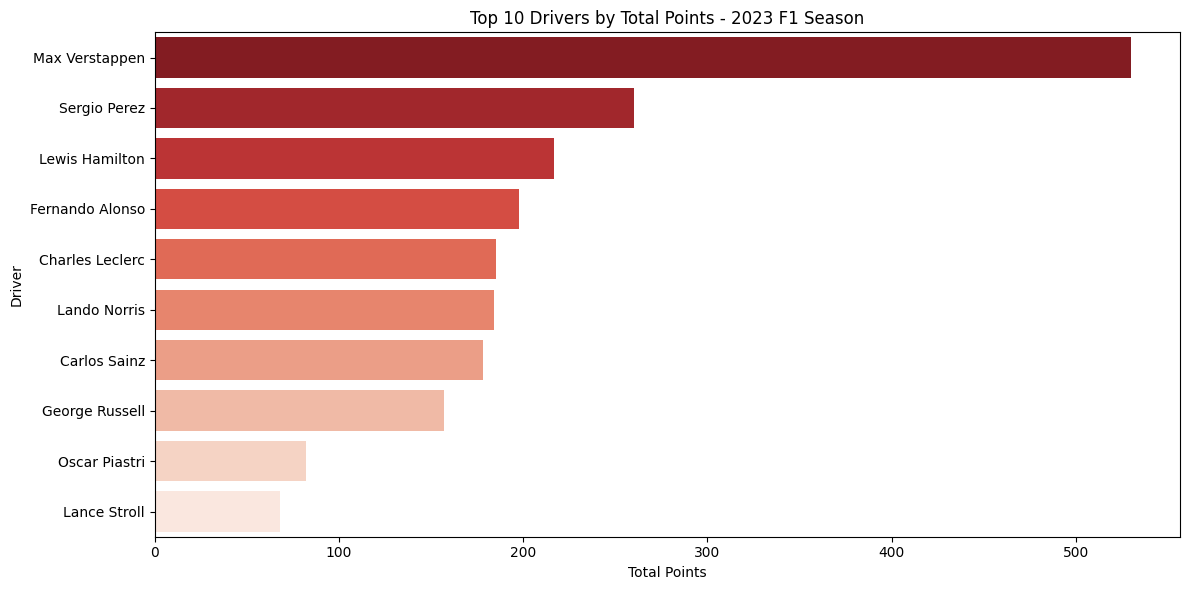

In [6]:
top_drivers = df.groupby('driver_name')['points'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_drivers.values, y=top_drivers.index, palette='Reds_r')
plt.title('Top 10 Drivers by Total Points - 2023 F1 Season')
plt.xlabel('Total Points')
plt.ylabel('Driver')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2249/3667607862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='Blues_r')


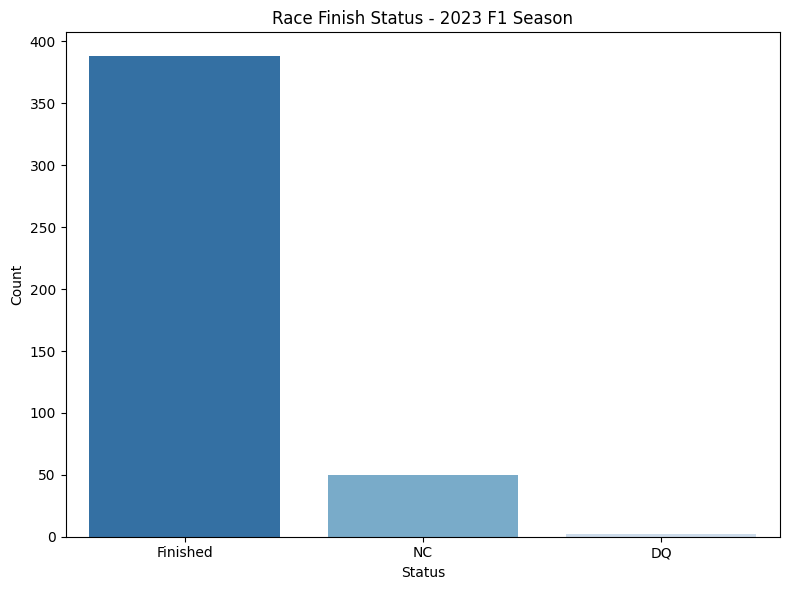

position_status
Finished    388
NC           50
DQ            2
Name: count, dtype: int64


In [7]:
status_counts = df['position_status'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='Blues_r')
plt.title('Race Finish Status - 2023 F1 Season')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(status_counts)

/tmp/ipykernel_2249/1431400123.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nationality_counts.values, y=nationality_counts.index, palette='Greens_r')


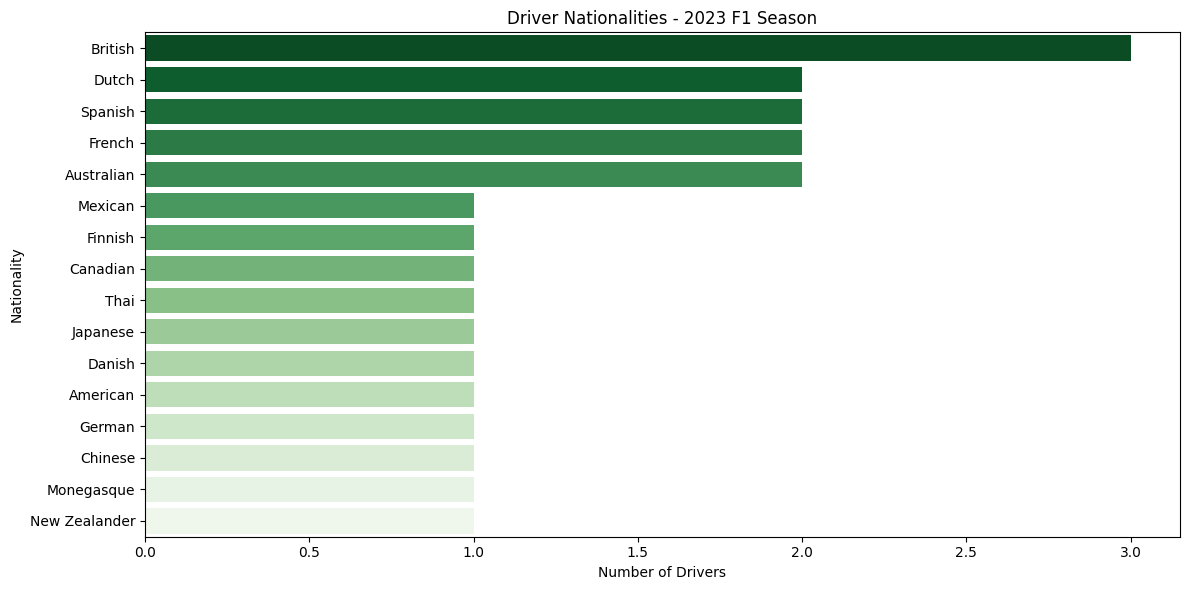

nationality
British          3
Dutch            2
Spanish          2
French           2
Australian       2
Mexican          1
Finnish          1
Canadian         1
Thai             1
Japanese         1
Danish           1
American         1
German           1
Chinese          1
Monegasque       1
New Zealander    1
Name: count, dtype: int64


In [8]:
nationality_counts = df[['driver_name', 'nationality']].drop_duplicates()['nationality'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=nationality_counts.values, y=nationality_counts.index, palette='Greens_r')
plt.title('Driver Nationalities - 2023 F1 Season')
plt.xlabel('Number of Drivers')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

print(nationality_counts)

/tmp/ipykernel_2249/2161679008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='length_km', y='track', data=circuit_lengths, palette='Oranges_r')


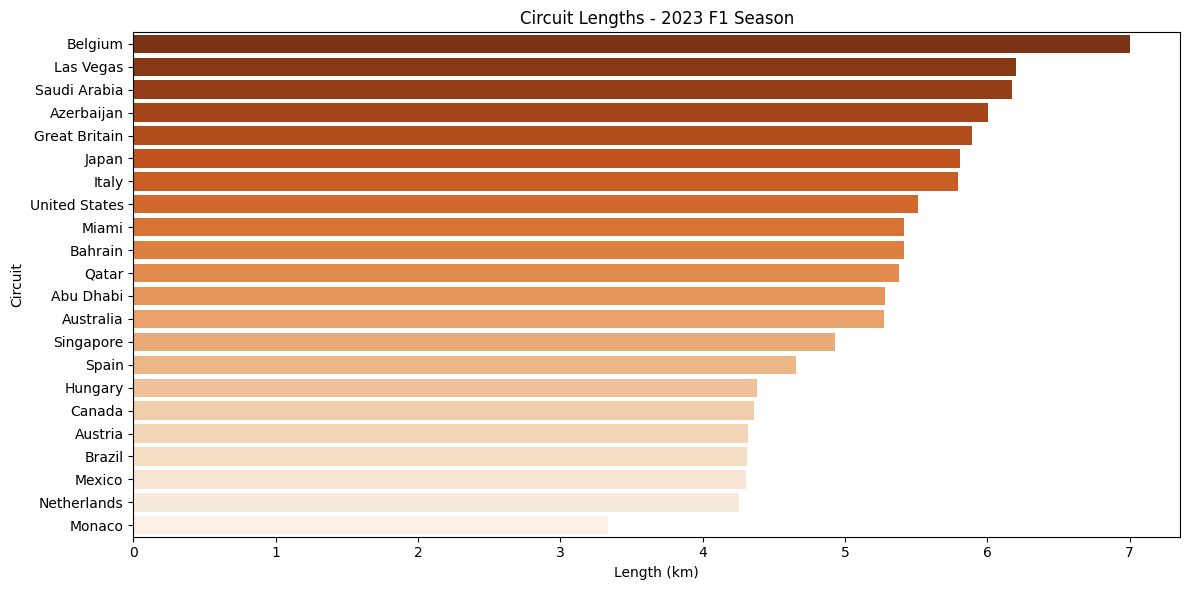

In [9]:
circuit_lengths = df[['track', 'length_km']].drop_duplicates().sort_values('length_km', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='length_km', y='track', data=circuit_lengths, palette='Oranges_r')
plt.title('Circuit Lengths - 2023 F1 Season')
plt.xlabel('Length (km)')
plt.ylabel('Circuit')
plt.tight_layout()
plt.show()

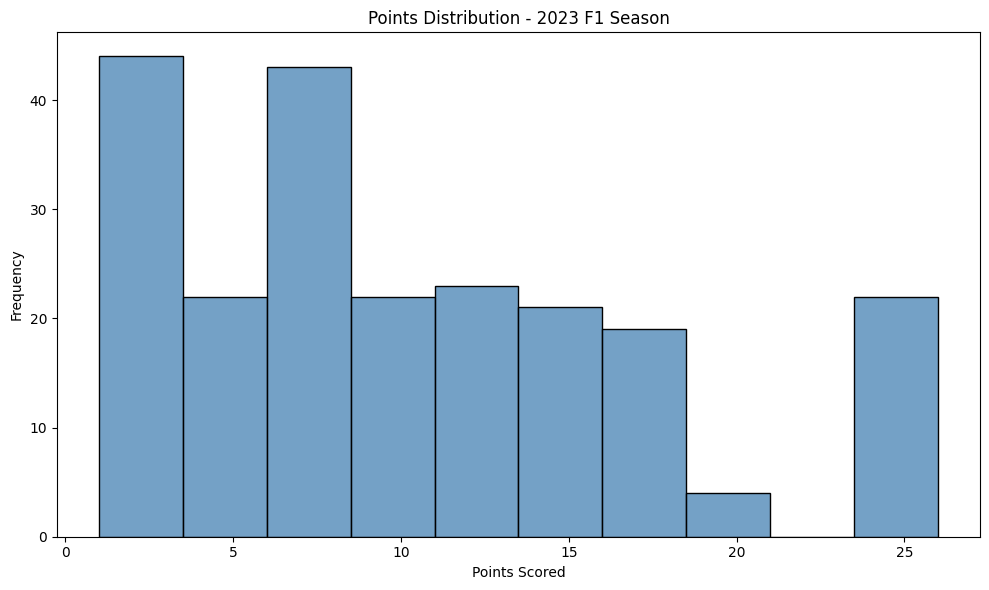

points
26      8
25     14
19      4
18     18
16      1
15     21
13      2
12     20
11      1
10     21
9       1
8      21
6      22
5       2
4      20
2      23
1      21
0     220
Name: count, dtype: int64


In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['points'] > 0]['points'], bins=10, color='steelblue')
plt.title('Points Distribution - 2023 F1 Season')
plt.xlabel('Points Scored')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(df['points'].value_counts().sort_index(ascending=False))